ARTI406 - Machine Learning
# Assignment 2: Data Quality Assessment & Preprocessing

Here I used my dataset from Assignment 1 (`car-sales-saudia.csv`) and did the preprocessing steps from class.


In [1]:
# Import Libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

## 1) Load the Dataset


In [2]:
pd.set_option('display.max_columns', None)

df = pd.read_csv('../Assigment1/car-sales-saudia.csv')
df.head(10)


,Brand,Price,Body,Mileage,EngineV,Engine Type,Registration,Year,Model
0,BMW,4200.0,sedan,277,2.0,Petrol,yes,1991,320
1,Mercedes-Benz,7900.0,van,427,2.9,Diesel,yes,1999,Sprinter 212
2,Mercedes-Benz,13300.0,sedan,358,5.0,Gas,yes,2003,S 500
3,Audi,23000.0,crossover,240,4.2,Petrol,yes,2007,Q7
4,Toyota,18300.0,crossover,120,2.0,Petrol,yes,2011,Rav 4
5,Mercedes-Benz,199999.0,crossover,0,5.5,Petrol,yes,2016,GLS 63
6,BMW,6100.0,sedan,438,2.0,Gas,yes,1997,320
7,Audi,14200.0,vagon,200,2.7,Diesel,yes,2006,A6
8,Renault,10799.0,vagon,193,1.5,Diesel,yes,2012,Megane
9,Volkswagen,1400.0,other,212,1.8,Gas,no,1999,Golf IV


## 2) Data Quality Check
### 2.1 Check data types
First I check if the column types make sense before cleaning.


In [3]:
df.dtypes

Brand            object
Price           float64
Body             object
Mileage           int64
EngineV         float64
Engine Type      object
Registration     object
Year              int64
Model            object
dtype: object

Sometimes numbers are stored badly, so I check numeric columns first.


### 2.2 Fix data types
I convert these to numeric:
- `Price`
- `Mileage`
- `EngineV`
- `Year`


In [4]:
numeric_cols = ['Price', 'Mileage', 'EngineV', 'Year']
for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')

df.dtypes


Brand            object
Price           float64
Body             object
Mileage           int64
EngineV         float64
Engine Type      object
Registration     object
Year              int64
Model            object
dtype: object

If any value is invalid, it becomes `NaN` and I handle it in missing values step.


## 3) Missing Values
### 3.1 Find missing values
I check how many missing values are in each column.


In [5]:
df.isna().sum()

Brand             0
Price           172
Body              0
Mileage           0
EngineV         150
Engine Type       0
Registration      0
Year              0
Model             0
dtype: int64

From this output I can see which columns need treatment.


### 3.2 Add sample missing values
For practice, I add few extra missing values in `Price` to test methods.


In [6]:
df_missing = df.copy()
df_missing.loc[0:5, 'Price'] = np.nan
df_missing.isna().sum()


Brand             0
Price           178
Body              0
Mileage           0
EngineV         150
Engine Type       0
Registration      0
Year              0
Model             0
dtype: int64

Now `Price` has extra missing values for testing.


In [7]:
print("Original shape: ",df.shape)
print("After removing some values: ",df_missing.shape)

Original shape:  (4345, 9)
After removing some values:  (4345, 9)


In [8]:
df_missing.head(10)

,Brand,Price,Body,Mileage,EngineV,Engine Type,Registration,Year,Model
0,BMW,NaN,sedan,277,2.0,Petrol,yes,1991,320
1,Mercedes-Benz,NaN,van,427,2.9,Diesel,yes,1999,Sprinter 212
2,Mercedes-Benz,NaN,sedan,358,5.0,Gas,yes,2003,S 500
3,Audi,NaN,crossover,240,4.2,Petrol,yes,2007,Q7
4,Toyota,NaN,crossover,120,2.0,Petrol,yes,2011,Rav 4
5,Mercedes-Benz,NaN,crossover,0,5.5,Petrol,yes,2016,GLS 63
6,BMW,6100.0,sedan,438,2.0,Gas,yes,1997,320
7,Audi,14200.0,vagon,200,2.7,Diesel,yes,2006,A6
8,Renault,10799.0,vagon,193,1.5,Diesel,yes,2012,Megane
9,Volkswagen,1400.0,other,212,1.8,Gas,no,1999,Golf IV


### Method 1: Drop rows
Remove rows that contain missing values.


In [9]:
df_removed = df_missing.dropna()
df_removed.shape

(4019, 9)

In [10]:
df_removed.isna().sum()

Brand           0
Price           0
Body            0
Mileage         0
EngineV         0
Engine Type     0
Registration    0
Year            0
Model           0
dtype: int64

Easy way, but if many rows are removed we lose useful data.


### Method 2: Mean imputation
Fill missing `Price` with the mean.


In [11]:
df_missing.head(10)

,Brand,Price,Body,Mileage,EngineV,Engine Type,Registration,Year,Model
0,BMW,NaN,sedan,277,2.0,Petrol,yes,1991,320
1,Mercedes-Benz,NaN,van,427,2.9,Diesel,yes,1999,Sprinter 212
2,Mercedes-Benz,NaN,sedan,358,5.0,Gas,yes,2003,S 500
3,Audi,NaN,crossover,240,4.2,Petrol,yes,2007,Q7
4,Toyota,NaN,crossover,120,2.0,Petrol,yes,2011,Rav 4
5,Mercedes-Benz,NaN,crossover,0,5.5,Petrol,yes,2016,GLS 63
6,BMW,6100.0,sedan,438,2.0,Gas,yes,1997,320
7,Audi,14200.0,vagon,200,2.7,Diesel,yes,2006,A6
8,Renault,10799.0,vagon,193,1.5,Diesel,yes,2012,Megane
9,Volkswagen,1400.0,other,212,1.8,Gas,no,1999,Golf IV


In [12]:
df_imputed_mean = df_missing.copy()

mean_value = df_imputed_mean['Price'].mean()
df_imputed_mean['Price'] = df_imputed_mean['Price'].fillna(mean_value)

df_imputed_mean.isna().sum()


Brand             0
Price             0
Body              0
Mileage           0
EngineV         150
Engine Type       0
Registration      0
Year              0
Model             0
dtype: int64

In [13]:
df_imputed_mean.head(10)

,Brand,Price,Body,Mileage,EngineV,Engine Type,Registration,Year,Model
0,BMW,19382.705054,sedan,277,2.0,Petrol,yes,1991,320
1,Mercedes-Benz,19382.705054,van,427,2.9,Diesel,yes,1999,Sprinter 212
2,Mercedes-Benz,19382.705054,sedan,358,5.0,Gas,yes,2003,S 500
3,Audi,19382.705054,crossover,240,4.2,Petrol,yes,2007,Q7
4,Toyota,19382.705054,crossover,120,2.0,Petrol,yes,2011,Rav 4
5,Mercedes-Benz,19382.705054,crossover,0,5.5,Petrol,yes,2016,GLS 63
6,BMW,6100.000000,sedan,438,2.0,Gas,yes,1997,320
7,Audi,14200.000000,vagon,200,2.7,Diesel,yes,2006,A6
8,Renault,10799.000000,vagon,193,1.5,Diesel,yes,2012,Megane
9,Volkswagen,1400.000000,other,212,1.8,Gas,no,1999,Golf IV


This keeps all rows, but mean can be affected by outliers.


### Method 3: Median imputation
Fill missing `Price` with the median.


In [14]:
df_imputed_median = df_missing.copy()

median_value = df_imputed_median['Price'].median()
df_imputed_median['Price'] = df_imputed_median['Price'].fillna(median_value)

df_imputed_median.isna().sum()


Brand             0
Price             0
Body              0
Mileage           0
EngineV         150
Engine Type       0
Registration      0
Year              0
Model             0
dtype: int64

In [15]:
df_imputed_median.head(10)

,Brand,Price,Body,Mileage,EngineV,Engine Type,Registration,Year,Model
0,BMW,11500.0,sedan,277,2.0,Petrol,yes,1991,320
1,Mercedes-Benz,11500.0,van,427,2.9,Diesel,yes,1999,Sprinter 212
2,Mercedes-Benz,11500.0,sedan,358,5.0,Gas,yes,2003,S 500
3,Audi,11500.0,crossover,240,4.2,Petrol,yes,2007,Q7
4,Toyota,11500.0,crossover,120,2.0,Petrol,yes,2011,Rav 4
5,Mercedes-Benz,11500.0,crossover,0,5.5,Petrol,yes,2016,GLS 63
6,BMW,6100.0,sedan,438,2.0,Gas,yes,1997,320
7,Audi,14200.0,vagon,200,2.7,Diesel,yes,2006,A6
8,Renault,10799.0,vagon,193,1.5,Diesel,yes,2012,Megane
9,Volkswagen,1400.0,other,212,1.8,Gas,no,1999,Golf IV


Median is usually better if data is not balanced.


## 4) Outliers
I use IQR method to detect unusual values in `Price`.


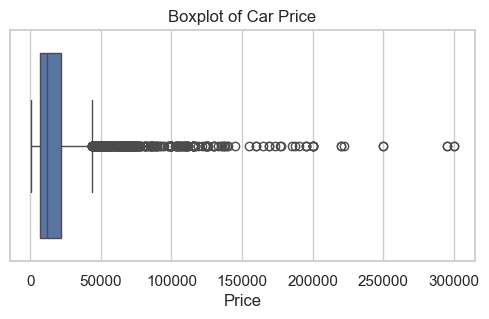

In [16]:
plt.figure(figsize=(6,3))
sns.boxplot(x=df['Price'])
plt.title('Boxplot of Car Price')
plt.show()


Points outside the boxplot whiskers are possible outliers.


### Detect outliers with IQR
Limits used:
- Lower = `Q1 - 1.5*IQR`
- Upper = `Q3 + 1.5*IQR`


In [17]:
Q1 = df['Price'].quantile(0.25)
Q3 = df['Price'].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers = df[(df['Price'] < lower) | (df['Price'] > upper)]
outliers.head(15)


,Brand,Price,Body,Mileage,EngineV,Engine Type,Registration,Year,Model
5,Mercedes-Benz,199999.0,crossover,0,5.50,Petrol,yes,2016,GLS 63
37,BMW,67500.0,crossover,1,2.50,Diesel,yes,2016,X5
41,Mercedes-Benz,63000.0,crossover,86,5.50,Petrol,yes,2009,G 55 AMG
62,BMW,133000.0,crossover,7,4.40,Petrol,yes,2015,X5 M
64,Mercedes-Benz,50000.0,sedan,240,3.50,Petrol,yes,2006,S 350
67,Audi,69999.0,crossover,21,3.00,Petrol,yes,2015,A6 Allroad
104,Mercedes-Benz,107999.0,crossover,0,2.98,Diesel,yes,2016,GLS 350
109,BMW,45500.0,crossover,76,4.40,Petrol,yes,2010,X6 M
111,BMW,47000.0,other,5,2.00,Petrol,yes,2014,Z4
119,BMW,46800.0,sedan,33,2.00,Diesel,yes,2014,520


These rows have prices outside the normal IQR range.


### Remove outliers


In [18]:
df_no_outliers = df[(df['Price'] >= lower) & (df['Price'] <= upper)]
print('Original shape:', df.shape)
print('After removing outliers:', df_no_outliers.shape)


Original shape: (4345, 9)
After removing outliers: (3803, 9)


Removing outliers helps, but some high/low prices can still be real cars.


### Cap outliers (percentiles)
Instead of deleting, I cap prices at 5th and 95th percentile.


In [19]:
lower_cap = df['Price'].quantile(0.05)
upper_cap = df['Price'].quantile(0.95)

df_capped = df.copy()
df_capped['Price'] = df_capped['Price'].clip(lower_cap, upper_cap)
df_capped[['Price']].describe()


,Price
count,4173.000000
mean,17301.068131
std,15863.248787
min,2600.000000
25%,6999.000000
50%,11500.000000
75%,21700.000000
max,63700.000000


## 5) Normalization
I scale `Price` and `Mileage` to similar range.

### Min-Max scaling


In [20]:
df[['Price', 'Mileage']].head()


,Price,Mileage
0,4200.0,277
1,7900.0,427
2,13300.0,358
3,23000.0,240
4,18300.0,120


In [21]:
# Min-Max scaling without sklearn

df_scaled = df[['Price', 'Mileage']].copy()
for col in ['Price', 'Mileage']:
    col_min = df_scaled[col].min()
    col_max = df_scaled[col].max()
    df_scaled[col] = (df_scaled[col] - col_min) / (col_max - col_min)

df_scaled.head()


,Price,Mileage
0,0.012024,0.282653
1,0.024382,0.435714
2,0.042418,0.365306
3,0.074816,0.244898
4,0.059118,0.122449


After Min-Max, values are between `[0, 1]`.


### Z-score standardization
This makes mean near 0 and std near 1.


In [22]:
# Z-score standardization without sklearn

df_standardized = df[['Price', 'Mileage']].copy()
for col in ['Price', 'Mileage']:
    mean = df_standardized[col].mean()
    std = df_standardized[col].std()
    df_standardized[col] = (df_standardized[col] - mean) / std

df_standardized.head()


,Price,Mileage
0,-0.594848,1.095141
1,-0.450228,2.514174
2,-0.239161,1.861418
3,0.139979,0.745113
4,-0.043728,-0.390114


Useful when features have very different scales.


## Check correlation before PCA
I check correlation between features before PCA.


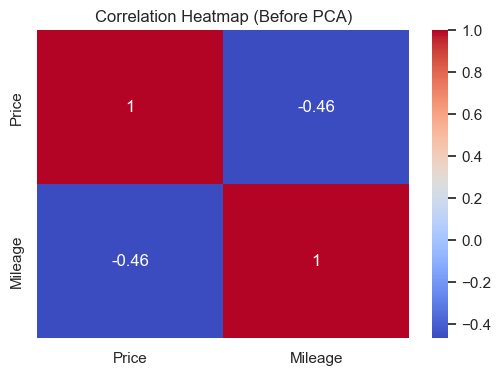

In [23]:
plt.figure(figsize=(6,4))
sns.heatmap(df_standardized[['Price','Mileage']].corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap (Before PCA)')
plt.show()


This heatmap shows relation between `Price` and `Mileage`.


## 6) PCA
PCA reduces dimensions and keeps most important variance.


### Simple idea
Use `Price` and `Mileage`, then project to principal components.


In [24]:
# PCA without sklearn (eigendecomposition of covariance matrix)

X = df_standardized[['Price', 'Mileage']].dropna().values
cov_matrix = np.cov(X, rowvar=False)

eigenvalues, eigenvectors = np.linalg.eig(cov_matrix)
sorted_idx = np.argsort(eigenvalues)[::-1]
eigenvalues = eigenvalues[sorted_idx]
eigenvectors = eigenvectors[:, sorted_idx]

principal_components = X @ eigenvectors[:, :2]
explained_variance_ratio = eigenvalues / eigenvalues.sum()

print('Explained Variance Ratio:', explained_variance_ratio[:2])


Explained Variance Ratio: [0.73242716 0.26757284]


Explained variance ratio tells how much info each component keeps.


In [25]:
# In addition to the heatmap, we can visualize the relationship between two features.
# plt.figure(figsize=(6,4))
# plt.scatter(df_standardized['Price'], df_standardized['Mileage'])
# plt.xlabel('Price (Standardized)')
# plt.ylabel('Mileage (Standardized)')
# plt.title('Scatter Plot: Price vs Mileage')
# plt.show()


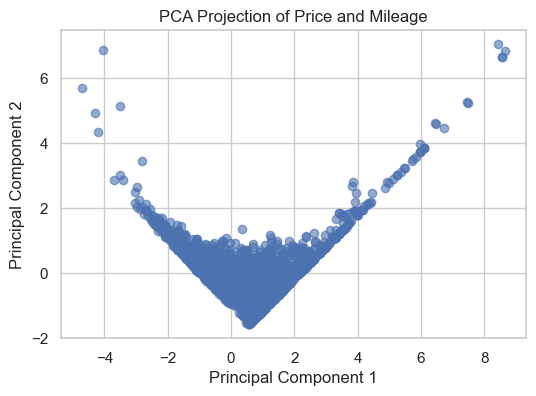

In [26]:
plt.figure(figsize=(6,4))
plt.scatter(principal_components[:, 0], principal_components[:, 1], alpha=0.6)
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title('PCA Projection of Price and Mileage')
plt.grid(True)
plt.show()


Each point is one car after projection on PC1 and PC2.


# Assignment Tasks
- Task 1: Identify data quality issues.
- Task 2: Apply one missing-value method and explain why.
- Task 3: Detect and handle outliers using IQR.
- Task 4: Normalize features and apply PCA.
